In [70]:
from itertools import product
from pathlib import Path

import fire
import numpy as np
import torch
from jsonlines import jsonlines
from loguru import logger
from torch.utils.data import DataLoader, TensorDataset

from heisenberg_hamiltonians import HeisenbergJ1J2
from misc_utils import torch_overlap as overlap
from my_stopwatch import stopwatch
from nqs_playground_helpers import SamplingOptions, sample_exactly
from spin_lattices import KagomeLattice
from swo import generate_training_set, generate_training_set_lanczos
from vmc_amplitude import LogProbDenseNet, almost_true_relsigns
import pandas as pd
import seaborn as sns

In [71]:
def true_amplitudes(system, states):
    return torch.from_numpy(np.abs(system.get_ground_state_coeffs(states))).float()


In [ ]:
def overlap_

In [72]:
lattice = KagomeLattice(2, 4)
system = HeisenbergJ1J2(
    lattice=lattice,
    J1=1.0,
    J2=1.0,
    use_symmetries=False,
    spin_inversion=None,
)
system.get_eigenstates(2)
all_states, _ = sample_exactly(
#        target_prob_fn,
    lambda s: torch.log(torch.from_numpy(true_amplitudes(system, s).detach().numpy()).float()) * 2,
    system.canonical_basis,
    SamplingOptions(
        number_samples=1000,
        number_chains=1,
        mode="exact",
        sweep_size=1,
        number_discarded=0,
    ),
    return_all_probs=False,
)
all_states

2023-09-11 18:29:08.204 | DEBUG    | heisenberg_hamiltonians:__init__:482 - number_spins=24
2023-09-11 18:29:08.250 | DEBUG    | heisenberg_hamiltonians:__init__:492 - Symmetry group contains 0 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-09-11 18:29:09.745 | DEBUG    | heisenberg_hamiltonians:__init__:501 - Hilbert space dimension is 2704156
2023-09-11 18:29:09.832 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-False-None-10.pickle
2023-09-11 18:29:12.026 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:121 - Ground state energy is -43.0395889923
2023-09-11 18:29:12.028 | DEBUG    | nqs_playground_helpers:_determine_batch_size:185 - 'batch_size' not specified, will use the default value of 8192.
2023-09-11 18:29:12.030 | DEBUG    | nqs_playground_helpers:sample_full:295 - Applying 'log_prob_fn' to all basis vectors in the Hilbe

tensor([[10544311],
        [ 3791235],
        [ 3651908],
        [ 1220045],
        [10827037],
        [12150369],
        [16533080],
        [ 8968629],
        [ 6072034],
        [ 8575323],
        [15800086],
        [ 9869542],
        [ 3831201],
        [11965772],
        [ 6482119],
        [ 4663094],
        [12150348],
        [ 3881289],
        [  445390],
        [ 3619142],
        [ 8820342],
        [  841421],
        [ 8034609],
        [ 4645710],
        [ 5485770],
        [13568570],
        [14870693],
        [ 3847497],
        [ 1690570],
        [10697043],
        [13383372],
        [16566664],
        [ 4834233],
        [  883313],
        [ 1783205],
        [11061082],
        [ 8575411],
        [ 8034705],
        [14234337],
        [ 1285580],
        [12929437],
        [14469730],
        [ 8705207],
        [ 3049261],
        [10030905],
        [11998802],
        [10607813],
        [ 9755036],
        [ 2805145],
        [ 1504458],


In [60]:
n_samples_list = [20000]
lattice_list = [KagomeLattice(2, 4)]
epochs_list = [100]
task_id = 0

configs = list(product(n_samples_list, lattice_list, epochs_list))
n_samples, lattice, epochs = configs[task_id]
run = task_id // len(configs)

output = []

test_samples = 50000
lr = 1e-3
n_hidden = 512
batch_size = 64

params_dict = {
    "run": run,
    "n_samples": n_samples,
    "lattice": lattice.get_cache_id(),
    "n_spins": lattice.number_spins,
    "epochs": epochs,
}

system = HeisenbergJ1J2(
    lattice=lattice,
    J1=1.0,
    use_symmetries=False,
    spin_inversion=None,
)
system_nosym = system

system.get_eigenstates(1)

stopwatch.reset()

log_prob_fn = LogProbDenseNet(system_nosym, n_hidden=n_hidden)
target_prob_fn = LogProbDenseNet(system_nosym, n_hidden=n_hidden)

optimizer = torch.optim.Adam(log_prob_fn.parameters(), lr=lr)
criterion = torch.nn.MSELoss()
for _ in range(1):
    logger.info(f"Sampling")
    all_states, _ = sample_exactly(
#        target_prob_fn,
        lambda s: torch.log(torch.from_numpy(true_amplitudes(system, s).detach().numpy()).float()) * 2,
        system.canonical_basis,
        SamplingOptions(
            number_samples=n_samples + test_samples,
            number_chains=1,
            mode="exact",
            sweep_size=1,
            number_discarded=0,
        ),
        return_all_probs=False,
    )
    logger.info("Sampling successful")
    all_states = all_states.view(-1)
    states = all_states[:n_samples]
    states_validation = all_states[n_samples:]

    remaining_states = np.delete(
        system.canonical_basis.states,
        system.canonical_basis.index(all_states.detach().numpy()),
    )
    states_test_uniform = torch.from_numpy(
        np.random.choice(remaining_states, test_samples, replace=True).astype(np.int64)
    ).long()
    # #            all_states = np.concatenate([states.detach().numpy(), states_test.detach().numpy()])
    # logger.info("Test states sampled")

    all_target = np.log(true_amplitudes(system, all_states.detach().numpy()).detach().numpy()) * 2
    # all_target = target_prob_fn(all_states).detach().numpy()

    target = torch.from_numpy(all_target[:n_samples]).float()
    target_validation = torch.from_numpy(all_target[n_samples:]).float()

    # Create a TensorDataset from your inputs X and Y
    dataset = TensorDataset(states, target)

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # log_prob_fn = LogProbDenseNet(system, n_hidden=n_hidden)

    # optimizer = torch.optim.Adam(log_prob_fn.parameters(), lr=lr)

    # writer = SummaryWriter(
    #     log_dir=(
    #         f"experiments/{datetime.now().strftime('%Y_%m_%d')}_dense_xor_supervised/{datetime.now().strftime('%H_%M_%S')}"
    #         #        f"xor={xor_masks_idxs}_ch=_{channels}_{lr=}_{blocks=}"
    #     )
    # )

    # initial_ground_state_overlap_full = overlap(
    #     torch.exp(log_prob_fn(system.canonical_basis.states).view(-1) * 0.5),
    #     true_amplitudes(system, system.canonical_basis.states),
    # )

    # initial_ground_state_overlap_train = overlap(
    #     torch.exp(log_prob_fn(states).view(-1) * 0.5),
    #     true_amplitudes(system, states),
    # )

    # initial_ground_state_overlap_test = overlap(
    #     torch.exp(log_prob_fn(states_test_uniform).view(-1) * 0.5),
    #     true_amplitudes(system, states_test_uniform),
    # )

    # target_ground_state_overlap_train = overlap(
    #     torch.exp(target.view(-1) * 0.5), true_amplitudes(system, states)
    # )

    # target_ground_state_overlap_test = overlap(
    #     torch.exp(target_test.view(-1) * 0.5), true_amplitudes[system.basis.index(states_test)]
    # )
    logger.info("Starting training")
    for epoch in range(epochs):
        logger.info(f"Running epoch {epoch}")
        running_loss = 0.0
        for action_index, data in enumerate(dataloader, 0):
            # Get the inputs and move them to the specified device
            inputs, log_probs = data

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = log_prob_fn(inputs)

            # weights = torch.exp(2 * log_amplitudes)
            # weights = weights / torch.sum(weights)

            # Compute loss
            loss = criterion(
                outputs, log_probs.view(-1, 1)
            )  # Reshape labels to match output shape
            # loss = 1 - overlap(
            #     differentiable_safe_exp(outputs.view(-1) * 0.5),
            #     differentiable_safe_exp(log_probs * 0.5),
            # )
            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Collect loss
            running_loss += loss.item()
        logger.info(f"Loss: {running_loss / len(dataloader)}")
        loss_validation = criterion(
            log_prob_fn(states_validation), target_validation.view(-1, 1)
        ).item()

        output.append(
            {
                "epoch": epoch,
                "loss_train": running_loss / len(dataloader),
                "loss_validation": loss_validation,
            }
            | params_dict
        )

    # new_ground_state_overlap_full = overlap(
    #     torch.exp(log_prob_fn(system.canonical_basis.states).view(-1) * 0.5),
    #     true_amplitudes(system, system.canonical_basis.states),
    # )

    logger.info("Finished training step")

    # new_ground_state_overlap_train = overlap(
    #     torch.exp(log_prob_fn(states).view(-1) * 0.5),
    #     true_amplitudes(system, states),
    # )

    new_ground_state_overlap_test = overlap(
        torch.exp(log_prob_fn(states_test_uniform).view(-1) * 0.5),
        true_amplitudes(system, states_validation),
    )

    # new_ground_state_overlap_full = overlap(
    #     torch.exp(log_prob_fn(system.canonical_basis.states).view(-1) * 0.5),
    #     true_amplitudes(system, system.canonical_basis.states),
    # )

    # with jsonlines.open(output_dir / str(task_id) / "overlaps.jsonl", mode="a") as writer:
    #     writer.write(
    #         {
    #             "iteration": iteration,
    #             "initial_ground_state_overlap_full": initial_ground_state_overlap_full.item(),
    #             # "initial_ground_state_overlap_train": initial_ground_state_overlap_train.item(),
    #             "initial_ground_state_overlap_test": initial_ground_state_overlap_test.item(),
    #             # "target_ground_state_overlap_train": target_ground_state_overlap_train.item(),
    #             #            "target_ground_state_overlap_test": target_ground_state_overlap_test.item(),
    #             "new_ground_state_overlap_full": new_ground_state_overlap_full.item(),
    #             # "new_ground_state_overlap_train": new_ground_state_overlap_train.item(),
    #             "new_ground_state_overlap_test": new_ground_state_overlap_test.item(),
    #             "alpha": alpha.real if alpha is not None else None,
    #         }
    #         | params_dict
    #     )

    # # Add average loss per epoch to TensorBoard
    # writer.add_scalar("Training Loss", running_loss / len(dataloader), epoch)

    # Calculate overlaps and add them to TensorBoard
    # overlap_train = overlap(
    #     torch.exp(log_prob_fn(states).view(-1) * 0.5), torch.exp(target * 0.5)
    # )
    # logger.info(f"Overlap with target (train): {overlap_train.item()}")

    # overlap_test = overlap(
    #     torch.exp(log_prob_fn(states_test).view(-1) * 0.5),
    #     torch.exp(target_test * 0.5),
    # )
    # logger.info(f"Overlap with target (test): {overlap_test.item()}")

    # writer.add_scalar("train/overlap", overlap_train, epoch)
    # # writer.add_scalar('Overlap Test', overlap_test, epoch)
    # writer.add_scalar("test/overlap", overlap_test, epoch)

    # print("Finished Training")

2023-09-11 18:05:47.630 | DEBUG    | heisenberg_hamiltonians:__init__:482 - number_spins=24
2023-09-11 18:05:47.632 | DEBUG    | heisenberg_hamiltonians:__init__:492 - Symmetry group contains 0 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-09-11 18:05:47.759 | DEBUG    | heisenberg_hamiltonians:__init__:501 - Hilbert space dimension is 2704156
2023-09-11 18:05:47.771 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-False-None-10.pickle
2023-09-11 18:05:48.268 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:121 - Ground state energy is -43.0395889923
2023-09-11 18:05:48.293 | INFO     | __main__:<module>:43 - Sampling
2023-09-11 18:05:48.295 | DEBUG    | nqs_playground_helpers:_determine_batch_size:185 - 'batch_size' not specified, will use the default value of 8192.
2023-09-11 18:05:48.297 | DEBUG    | nqs_playground_helpers:sampl

In [61]:
df = pd.DataFrame(output)

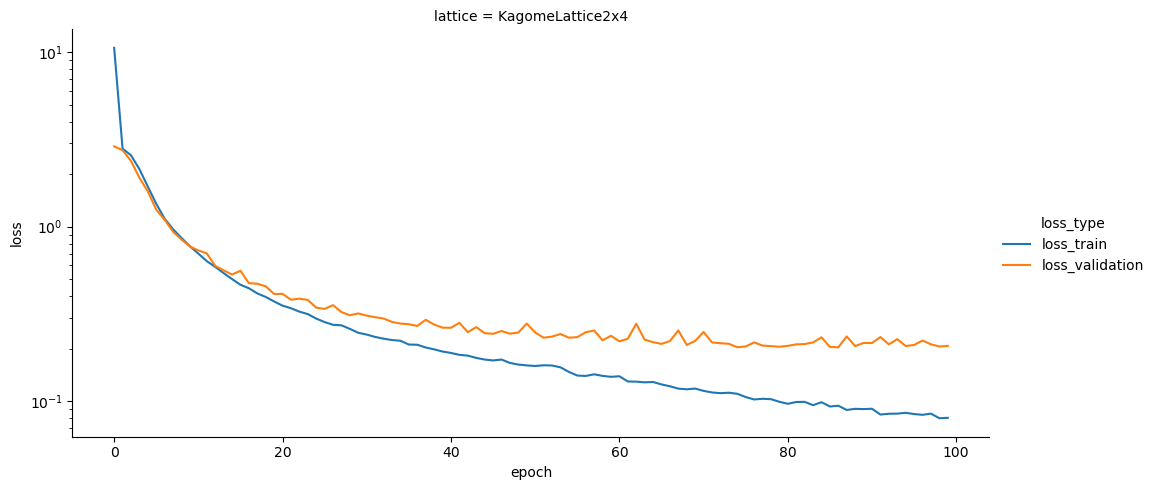

In [62]:
sns.relplot(
    df.melt(
        id_vars=["epoch", "lattice"],
        value_vars=["loss_train", "loss_validation"],
        var_name="loss_type",
        value_name="loss",
    ),
    x="epoch",
    y="loss",
    hue="loss_type",
    col="lattice",
    kind="line",
    aspect=2,
).set(yscale="log")

In [63]:
new_ground_state_overlap_test

tensor(0.4228, grad_fn=<DivBackward0>)

In [64]:
system.canonical_basis.states.shape[0] * 0.001

2704.156

In [65]:
new_ground_state_overlap_full = overlap(
        torch.exp(log_prob_fn(system.canonical_basis.states).view(-1) * 0.5),
        true_amplitudes(system, system.canonical_basis.states),
    )

In [68]:
overlap(
        torch.exp(log_prob_fn(states_validation).view(-1) * 0.5),
        true_amplitudes(system, states_validation),
    )

tensor(0.9925, grad_fn=<DivBackward0>)

In [74]:
torch.sum(
    torch.exp(log_prob_fn(states_validation).view(-1) * 0.5)
    / true_amplitudes(system, states_validation)
) / np.sqrt(states_validation.shape[0]) / torch.sum(
    torch.exp(log_prob_fn(states_validation).view(-1))
    / true_amplitudes(system, states_validation)
)

tensor(0.9876, grad_fn=<DivBackward0>)